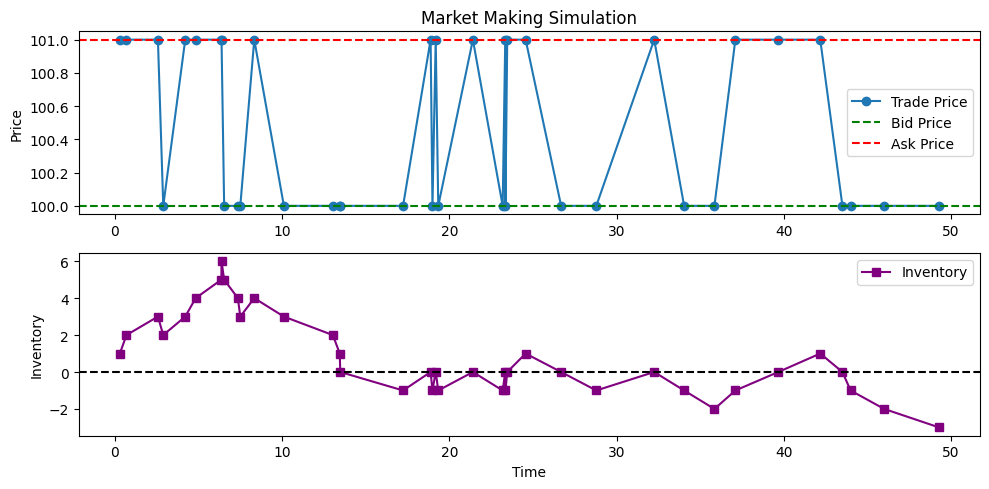

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import simpy

class MarketMaker:
    def __init__(self, env, bid_price, ask_price, spread, inventory=0):
        self.env = env
        self.bid_price = bid_price
        self.ask_price = ask_price
        self.spread = spread
        self.inventory = inventory
        self.trades = []
        self.env.process(self.simulate_trading())

    def simulate_trading(self):
        while True:
            yield self.env.timeout(np.random.exponential(1))  # Random arrival of orders
            trade_type = np.random.choice(["buy", "sell"], p=[0.5, 0.5])
            self.execute_trade(trade_type)

    def execute_trade(self, trade_type):
        if trade_type == "buy":
            self.inventory -= 1
            trade_price = self.bid_price
        else:
            self.inventory += 1
            trade_price = self.ask_price
        self.trades.append((self.env.now, trade_price, self.inventory))

# Simulation parameters
env = simpy.Environment()
initial_bid = 100
initial_ask = 101
spread = initial_ask - initial_bid
market_maker = MarketMaker(env, initial_bid, initial_ask, spread)
env.run(until=50)

# Extract trade data for visualization
times, prices, inventories = zip(*market_maker.trades)

# Plot price over time
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(times, prices, marker='o', linestyle='-', label='Trade Price')
plt.axhline(initial_bid, color='green', linestyle='--', label='Bid Price')
plt.axhline(initial_ask, color='red', linestyle='--', label='Ask Price')
plt.ylabel("Price")
plt.legend()
plt.title("Market Making Simulation")

# Plot inventory over time
plt.subplot(2, 1, 2)
plt.plot(times, inventories, marker='s', linestyle='-', color='purple', label='Inventory')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Inventory")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
!pip install simpy